In [ ]:
!pip install numpy==1.26.4


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 53.6 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ydf 0.11.0 requires protobuf<6.0.0,>=5.29.1, but you have protobuf 3.20.2 which is incompatible.
tensorflow 2.18.0 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0.0dev,>=3.20.3, but you have protobuf 3.20.2 which is incompatible.
thinc 8.3.6 requires numpy<3.0.0,>=2.0.0, but you have numpy 1.26.4 which is incompatible.


In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
from glob import glob
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, BatchNormalization, Flatten, Dense, Dropout, Concatenate, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.initializers import HeUniform
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, LearningRateScheduler
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
# Define the MobileNetV2-based model with L2 regularization and dropout
def build_mobilenetv2_model(input_shape=(224, 224, 3)):
    base_model = MobileNetV2(input_shape=input_shape, include_top=False, weights='imagenet')
    #Parameters:
    #input_shape: Defines the shape of the input tensor.
    #include_top=False: Excludes the fully connected layers at the top of the network. This allows to add custom layers for specific task.
    #weights='imagenet': Loads weights pre-trained on the ImageNet dataset.


    for layer in base_model.layers[:-30]:  #Freezes all layers except the last 30. This allows the last 30 layers to be fine-tuned for the new task, which help improve performance on the specific dataset.
        layer.trainable = False  # Freeze the initial layers

    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(64, activation='relu', kernel_regularizer=l2(0.02))(x)
    x = Dropout(0.6)(x)
    output = Dense(2, activation='softmax')(x)
    model = Model(inputs=base_model.input, outputs=output)
    return model

# Build the model
model = build_mobilenetv2_model(input_shape=(224, 224, 3))


# Print the model summary
model.summary()

import tf2onnx

# Save in native format (optional but preferred)
model.save("mobilenetv2_model.keras")

# Convert to ONNX
spec = (tf.TensorSpec((1, 224, 224, 3), tf.float32, name="input"),)
onnx_model, _ = tf2onnx.convert.from_keras(model, input_signature=spec, opset=13, output_path="mobilenetv2.onnx")



Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,340,098 (8.93 MB)

 Trainable params: 1,608,514 (6.14 MB)

 Non-trainable params: 731,584 (2.79 MB)

                                            filename label
0  /content/drive/MyDrive/NEW/dataset/DM group/DM...    DM
1  /content/drive/MyDrive/NEW/dataset/DM group/DM...    DM
2  /content/drive/MyDrive/NEW/dataset/DM group/DM...    DM
3  /content/drive/MyDrive/NEW/dataset/DM group/DM...    DM
4  /content/drive/MyDrive/NEW/dataset/DM group/DM...    DM
                                            filename    label
0  /content/drive/MyDrive/NEW/dataset/Control gro...  Control
1  /content/drive/MyDrive/NEW/dataset/Control gro...  Control
2  /content/drive/MyDrive/NEW/dataset/DM group/DM...       DM
3  /content/drive/MyDrive/NEW/dataset/DM group/DM...       DM
4  /content/drive/MyDrive/NEW/dataset/DM group/DM...       DM
                                            filename    label
0  /content/drive/MyDrive/NEW/dataset/Control gro...  Control
1  /content/drive/MyDrive/NEW/dataset/Control gro...  Control
2  /content/drive/MyDrive/NEW/dataset/DM group/DM...       DM
3  /content/drive/MyDrive/

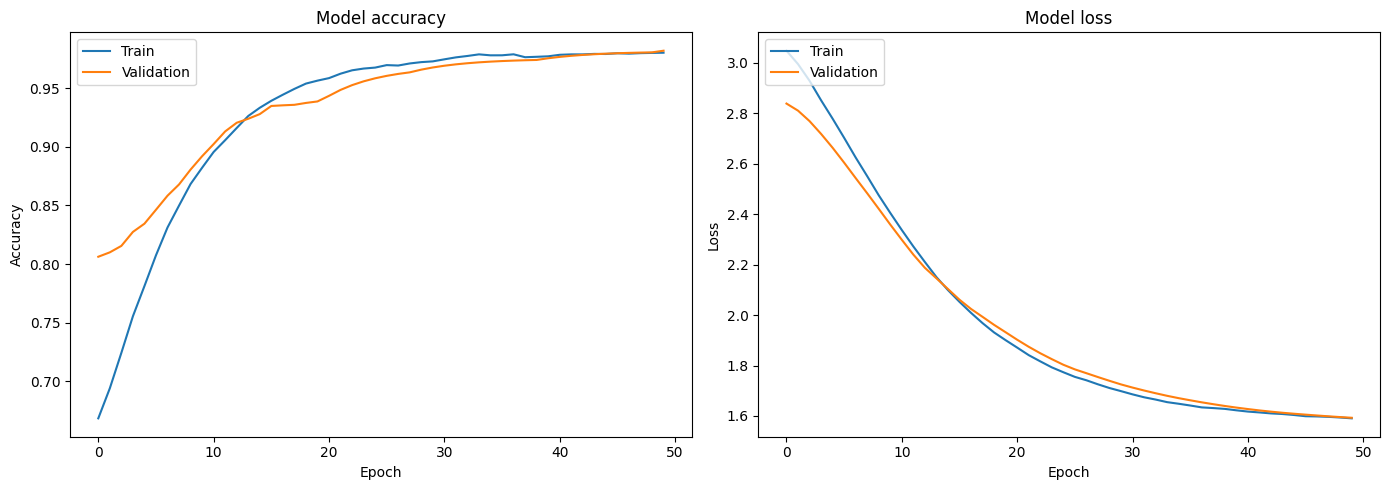

5/5 [==============================] - 47s 11s/step - loss: 1.6199 - accuracy: 0.9625
Test Loss: 1.619937539100647
Test Accuracy: 0.9624999761581421


/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
from glob import glob
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, BatchNormalization, Flatten, Dense, Dropout, Concatenate, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.initializers import HeUniform
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, LearningRateScheduler
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

# Define parameters
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
LEARNING_RATE = 3e-5
EPOCHS = 50
SEED = 42  #is often used as a default seed value

# Set the seed for reproducibility
np.random.seed(SEED) #sets the seed for NumPy's random number generator.
tf.random.set_seed(SEED) #sets the seed for TensorFlow's random number generator.

# Load the data from CSV files
train_data = pd.read_csv('/content/drive/MyDrive/NEW/train_data.csv')
val_data = pd.read_csv('/content/drive/MyDrive/NEW/val_data.csv')
test_data = pd.read_csv('/content/drive/MyDrive/NEW/test_data.csv')

# Define the base path to the dataset directory
base_path = '/content/drive/MyDrive/NEW'

# Update file paths
train_data['filename'] = train_data['filename'].apply(lambda x: os.path.join(base_path, x.replace('\\', '/')))
val_data['filename'] = val_data['filename'].apply(lambda x: os.path.join(base_path, x.replace('\\', '/')))
test_data['filename'] = test_data['filename'].apply(lambda x: os.path.join(base_path, x.replace('\\', '/')))

# Verify updated file paths
print(train_data.head())
print(val_data.head())
print(test_data.head())

# Check if files exist
train_filenames = train_data['filename'].tolist()
val_filenames = val_data['filename'].tolist()
test_filenames = test_data['filename'].tolist()

print(all(os.path.exists(filename) for filename in train_filenames))
print(all(os.path.exists(filename) for filename in val_filenames))
print(all(os.path.exists(filename) for filename in test_filenames))

# Create Data Generators with increased data augmentation
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=90,
    horizontal_flip=True,
)

val_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)
test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_generator = train_datagen.flow_from_dataframe(
    train_data,
    x_col='filename',
    y_col='label',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True,
    seed=SEED # Consistent shuffling
)

val_generator = val_datagen.flow_from_dataframe(
    val_data,
    x_col='filename',
    y_col='label',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False,
    seed=SEED # Consistent shuffling
)

test_generator = test_datagen.flow_from_dataframe(
    test_data,
    x_col='filename',
    y_col='label',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False,
    seed=SEED
)

# Verify the Split
print(f"Training samples: {train_generator.n}")
print(f"Validation samples: {val_generator.n}")
print(f"Testing samples: {test_generator.n}")

# Define the MobileNetV2-based model with L2 regularization and dropout
def build_mobilenetv2_model(input_shape=(224, 224, 3)):
    base_model = MobileNetV2(input_shape=input_shape, include_top=False, weights='imagenet')
    #Parameters:
    #input_shape: Defines the shape of the input tensor.
    #include_top=False: Excludes the fully connected layers at the top of the network. This allows to add custom layers for specific task.
    #weights='imagenet': Loads weights pre-trained on the ImageNet dataset.


    for layer in base_model.layers[:-30]:  #Freezes all layers except the last 30. This allows the last 30 layers to be fine-tuned for the new task, which help improve performance on the specific dataset.
        layer.trainable = False  # Freeze the initial layers

    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(64, activation='relu', kernel_regularizer=l2(0.02))(x)
    x = Dropout(0.6)(x)
    output = Dense(2, activation='softmax')(x)
    model = Model(inputs=base_model.input, outputs=output)
    return model

# Build the model
model = build_mobilenetv2_model(input_shape=(224, 224, 3))

# Compile the model with Adam optimizer
model.compile(optimizer=Adam(learning_rate=LEARNING_RATE), loss='categorical_crossentropy', metrics=['accuracy'])

# Print the model summary
model.summary()

# Define learning rate scheduler
  #For the first 10 epochs, the learning rate remains unchanged.
  #After the first 10 epochs, the learning rate decays exponentially.
  #LearningRateScheduler: A Keras callback that updates the learning rate at each epoch according to the scheduler function.
  #The scheduler function takes the epoch number and the current learning rate as input and returns the updated learning rate.
def scheduler(epoch, lr):
    if epoch < 10:
        return float(lr)
    else:
        return float(lr * tf.math.exp(-0.1))

lr_scheduler = LearningRateScheduler(scheduler)

# Define callbacks
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=5, min_lr=1e-6)  #Reduces the learning rate when a metric has stopped improving
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)  #Stops training when a monitored metric has stopped improving

# Train the model
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.n // BATCH_SIZE,
    validation_data=val_generator,
    validation_steps=val_generator.n // BATCH_SIZE,
    epochs=EPOCHS,
    callbacks=[reduce_lr, early_stopping, lr_scheduler]
)

# Smooth the training and validation curves
def smooth_curve(points, factor=0.8):
    smoothed_points = []
    for point in points:
        if smoothed_points:
            previous = smoothed_points[-1]
            smoothed_points.append(previous * factor + point * (1 - factor))
        else:
            smoothed_points.append(point)
    return smoothed_points

# Plot training history
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(smooth_curve(history.history['accuracy']), label='Train')
plt.plot(smooth_curve(history.history['val_accuracy']), label='Validation')
plt.title('Model accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.subplot(1, 2, 2)
plt.plot(smooth_curve(history.history['loss']), label='Train')
plt.plot(smooth_curve(history.history['val_loss']), label='Validation')
plt.title('Model loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()

# Evaluate the model on the test set
test_loss, test_accuracy = model.evaluate(test_generator, steps=test_generator.n // BATCH_SIZE)
print(f"Test Loss: {test_loss}")
print(f"Test Accuracy: {test_accuracy}")

# Save the final model
model.save('path_to_save_model/dfu_mobilenetv2.h5')

In [ ]:
# Load the data from CSV files
import pandas as pd
train_data = pd.read_csv('/content/drive/MyDrive/NEW/train_data.csv')
val_data = pd.read_csv('/content/drive/MyDrive/NEW/val_data.csv')
test_data = pd.read_csv('/content/drive/MyDrive/NEW/test_data.csv')

# Define the base path to your dataset directory
base_path = '/content/drive/MyDrive/NEW'
# Calculate the number of samples
total_samples = len(train_data) + len(val_data) + len(test_data)
train_percentage = (len(train_data) / total_samples) * 100
val_percentage = (len(val_data) / total_samples) * 100
test_percentage = (len(test_data) / total_samples) * 100

print(f"Training data: {len(train_data)} samples ({train_percentage:.2f}%)")
print(f"Validation data: {len(val_data)} samples ({val_percentage:.2f}%)")
print(f"Testing data: {len(test_data)} samples ({test_percentage:.2f}%)")

Training data: 1492 samples (79.96%)
Validation data: 187 samples (10.02%)
Testing data: 187 samples (10.02%)


In [ ]:
# Import the necessary library
from tensorflow.keras.applications import MobileNetV2

# Load MobileNetV2 model without the custom layers
base_model = MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights='imagenet')

# Count the total number of layers
total_layers = len(base_model.layers)

# Number of layers to freeze
layers_to_freeze = total_layers - 30

print(f"Total layers in MobileNetV2: {total_layers}")
print(f"Number of frozen layers: {layers_to_freeze}")


9406464/9406464 [==============================] - 0s 0us/step
Total layers in MobileNetV2: 154
Number of frozen layers: 124


1/1 [==============================] - 30s 30s/step
Predicted Class: Diabetic (DM)
Probabilities: [3.0957695e-04 9.9969041e-01]


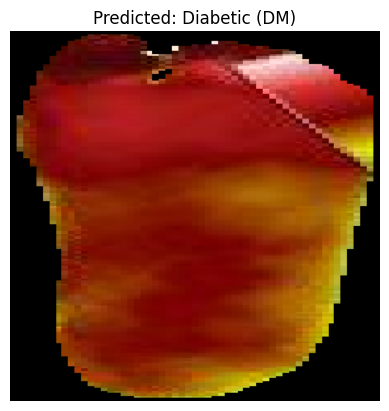

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
import matplotlib.pyplot as plt

# Load the trained model
model = tf.keras.models.load_model('/content/path_to_save_model/dfu_mobilenetv2.h5')

# Function to load and preprocess an image
def load_and_preprocess_image(img_path, target_size=(224, 224)):
    img = image.load_img(img_path, target_size=target_size)
    img_array = image.img_to_array(img)     #Converts the loaded image to a numpy array.
    img_array = np.expand_dims(img_array, axis=0)  #Adds an extra dimension to the array to match the expected input shape of the model.
    img_array = preprocess_input(img_array)  #Preprocesses the image for use with the MobileNetV2 model.
    return img_array

# Function to make a prediction
def predict_image_class(img_path):
    img_array = load_and_preprocess_image(img_path)
    predictions = model.predict(img_array)
    predicted_class = np.argmax(predictions, axis=1)  # returns the index of the class with the highest predicted probability.
    class_labels = {0: 'Normal (Control)', 1: 'Diabetic (DM)'}
    return class_labels[predicted_class[0]], predictions[0]

# Example usage
img_path = '/content/drive/MyDrive/dataset/DM group/DM001_M_L.png'  # Replace with the path to image
predicted_class, probabilities = predict_image_class(img_path)
print(f"Predicted Class: {predicted_class}")
print(f"Probabilities: {probabilities}")

# Plot the image with the prediction
img = image.load_img(img_path, target_size=(224, 224))
plt.imshow(img)
plt.title(f"Predicted: {predicted_class}")
plt.axis('off')
plt.show()


                                            filename    label
0  /content/drive/MyDrive/NEW/dataset/Control gro...  Control
1  /content/drive/MyDrive/NEW/dataset/Control gro...  Control
2  /content/drive/MyDrive/NEW/dataset/DM group/DM...       DM
3  /content/drive/MyDrive/NEW/dataset/Control gro...  Control
4  /content/drive/MyDrive/NEW/dataset/Control gro...  Control
All test filenames are valid.
Found 187 validated image filenames belonging to 2 classes.
6/6 [==============================] - 11s 2s/step
Sensitivity: 0.9285714285714286
Specificity: 1.0
              precision    recall  f1-score   support

     Control       0.93      1.00      0.96        89
          DM       1.00      0.93      0.96        98

    accuracy                           0.96       187
   macro avg       0.96      0.96      0.96       187
weighted avg       0.97      0.96      0.96       187



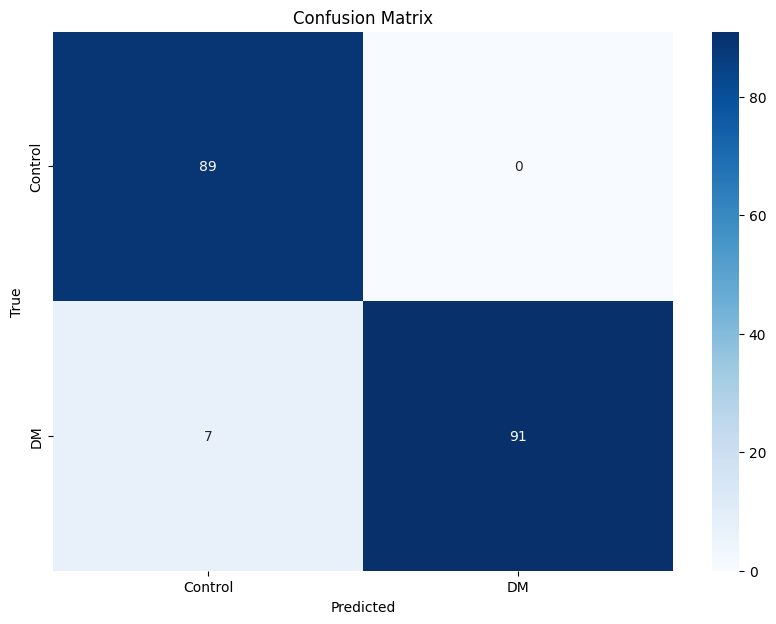

In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import seaborn as sns
import matplotlib.pyplot as plt
import os

# Define parameters
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

# Define the base path to dataset directory
base_path = '/content/drive/MyDrive/NEW'

# Load the data from CSV files
test_data = pd.read_csv('/content/drive/MyDrive/NEW/test_data.csv')

# Update file paths
def update_path(filepath):
    return os.path.join(base_path, filepath.replace('\\', '/')).strip()

test_data['filename'] = test_data['filename'].apply(update_path)

# Verify updated file paths
print(test_data.head())

# Identify invalid filenames
test_filenames = test_data['filename'].tolist()
invalid_test_files = [filename for filename in test_filenames if not os.path.exists(filename)]

# Print invalid filenames
if invalid_test_files:
    print(f"Invalid test filenames: {invalid_test_files[:10]}")  # Print first 10 invalid filenames for brevity
else:
    print("All test filenames are valid.")

# Create Data Generator
test_datagen = ImageDataGenerator(preprocessing_function=tf.keras.applications.mobilenet_v2.preprocess_input)

test_generator = test_datagen.flow_from_dataframe(
    test_data,
    x_col='filename',
    y_col='label',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False,
    seed=SEED
)

# Load the trained model
model = load_model('/content/path_to_save_model/dfu_mobilenetv2.h5')

# Make predictions on the test set
predictions = model.predict(test_generator, verbose=1)

# Get true labels
true_labels = test_generator.classes

# Get predicted labels
predicted_labels = np.argmax(predictions, axis=1)

# Confusion Matrix
cm = confusion_matrix(true_labels, predicted_labels)

# Calculate sensitivity and specificity
tn, fp, fn, tp = cm.ravel()

sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)

print(f"Sensitivity: {sensitivity}")
print(f"Specificity: {specificity}")

# Classification report
target_names = list(test_generator.class_indices.keys())
report = classification_report(true_labels, predicted_labels, target_names=target_names)
print(report)

# Plot confusion matrix
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()


In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os

# Define parameters
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

# Define the base path to dataset directory
base_path = '/content/drive/MyDrive/NEW'

# Load the data from CSV files
train_data = pd.read_csv('/content/drive/MyDrive/NEW/train_data.csv')
val_data = pd.read_csv('/content/drive/MyDrive/NEW/val_data.csv')
test_data = pd.read_csv('/content/drive/MyDrive/NEW/test_data.csv')

# Update file paths
def update_path(filepath):
    return os.path.join(base_path, filepath.replace('\\', '/')).strip()

train_data['filename'] = train_data['filename'].apply(update_path)
val_data['filename'] = val_data['filename'].apply(update_path)
test_data['filename'] = test_data['filename'].apply(update_path)

# Verify updated file paths
print(train_data.head())
print(val_data.head())
print(test_data.head())

# Identify invalid filenames
train_filenames = train_data['filename'].tolist()
val_filenames = val_data['filename'].tolist()
test_filenames = test_data['filename'].tolist()

invalid_train_files = [filename for filename in train_filenames if not os.path.exists(filename)]
invalid_val_files = [filename for filename in val_filenames if not os.path.exists(filename)]
invalid_test_files = [filename for filename in test_filenames if not os.path.exists(filename)]

# Print invalid filenames
if invalid_train_files:
    print(f"Invalid train filenames: {invalid_train_files[:10]}")  # Print first 10 invalid filenames for brevity
if invalid_val_files:
    print(f"Invalid validation filenames: {invalid_val_files[:10]}")  # Print first 10 invalid filenames for brevity
if invalid_test_files:
    print(f"Invalid test filenames: {invalid_test_files[:10]}")  # Print first 10 invalid filenames for brevity

# Create Data Generators
datagen = ImageDataGenerator(preprocessing_function=tf.keras.applications.mobilenet_v2.preprocess_input)

train_generator = datagen.flow_from_dataframe(
    train_data,
    x_col='filename',
    y_col='label',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False,
    seed=SEED
)

val_generator = datagen.flow_from_dataframe(
    val_data,
    x_col='filename',
    y_col='label',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False,
    seed=SEED
)

test_generator = datagen.flow_from_dataframe(
    test_data,
    x_col='filename',
    y_col='label',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False,
    seed=SEED
)

# Load the trained model
model = load_model('/content/path_to_save_model/dfu_mobilenetv2.h5')

# Evaluate the model on the training set
train_loss, train_accuracy = model.evaluate(train_generator, steps=train_generator.n // BATCH_SIZE)
print(f"Train Loss: {train_loss}")
print(f"Train Accuracy: {train_accuracy}")

# Evaluate the model on the validation set
val_loss, val_accuracy = model.evaluate(val_generator, steps=val_generator.n // BATCH_SIZE)
print(f"Validation Loss: {val_loss}")
print(f"Validation Accuracy: {val_accuracy}")

# Evaluate the model on the test set
test_loss, test_accuracy = model.evaluate(test_generator, steps=test_generator.n // BATCH_SIZE)
print(f"Test Loss: {test_loss}")
print(f"Test Accuracy: {test_accuracy}")


                                            filename label
0  /content/drive/MyDrive/NEW/dataset/DM group/DM...    DM
1  /content/drive/MyDrive/NEW/dataset/DM group/DM...    DM
2  /content/drive/MyDrive/NEW/dataset/DM group/DM...    DM
3  /content/drive/MyDrive/NEW/dataset/DM group/DM...    DM
4  /content/drive/MyDrive/NEW/dataset/DM group/DM...    DM
                                            filename    label
0  /content/drive/MyDrive/NEW/dataset/Control gro...  Control
1  /content/drive/MyDrive/NEW/dataset/Control gro...  Control
2  /content/drive/MyDrive/NEW/dataset/DM group/DM...       DM
3  /content/drive/MyDrive/NEW/dataset/DM group/DM...       DM
4  /content/drive/MyDrive/NEW/dataset/DM group/DM...       DM
                                            filename    label
0  /content/drive/MyDrive/NEW/dataset/Control gro...  Control
1  /content/drive/MyDrive/NEW/dataset/Control gro...  Control
2  /content/drive/MyDrive/NEW/dataset/DM group/DM...       DM
3  /content/drive/MyDrive/

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import tensorflow as tf

# Load the trained model
model = tf.keras.models.load_model('/content/path_to_save_model/dfu_mobilenetv2.h5')

# Convert the model to TensorFlow Lite format
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

# Specify the complete file path for the .tflite model
tflite_model_path = '/content/path_to_save_model/dfu_mobilenetv2.tflite'

# Save the converted model to a .tflite file
with open(tflite_model_path, 'wb') as f:
    f.write(tflite_model)

print(f"TFLite model saved at {tflite_model_path}")


TFLite model saved at /content/path_to_save_model/dfu_mobilenetv2.tflite


In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os

# Define parameters
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

# Load the data from CSV files
test_data = pd.read_csv('/content/drive/MyDrive/test_data.csv')

# Define the base path to dataset directory
base_path = '/content/drive/MyDrive/NEW'

# Update file paths
test_data['filename'] = test_data['filename'].apply(lambda x: os.path.join(base_path, x.replace('\\', '/')))

# Create Data Generator
test_datagen = ImageDataGenerator(preprocessing_function=tf.keras.applications.mobilenet_v2.preprocess_input)

test_generator = test_datagen.flow_from_dataframe(
    test_data,
    x_col='filename',
    y_col='label',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False,
    seed=SEED
)

# Load the TFLite model and allocate tensors
interpreter = tf.lite.Interpreter(model_path='/content/path_to_save_model/dfu_mobilenetv2.tflite')
interpreter.allocate_tensors()

# Get input and output details
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# Get test data and labels
test_images, test_labels = next(test_generator)
test_generator.reset()  # Reset generator to start from the beginning

# Prepare data to the required format
input_shape = input_details[0]['shape']

# Run the interpreter on each batch
predictions = []

for _ in range(len(test_generator)):
    images, labels = next(test_generator)
    for img in images:
        # Prepare the input
        img = np.expand_dims(img, axis=0).astype(np.float32)
        interpreter.set_tensor(input_details[0]['index'], img)

        # Run the model
        interpreter.invoke()

        # Get the output
        output = interpreter.get_tensor(output_details[0]['index'])
        predictions.append(output)

# Convert predictions to array
predictions = np.vstack(predictions)

# Get predicted labels
predicted_labels = np.argmax(predictions, axis=1)

# Get true labels
true_labels = test_generator.classes

# Calculate accuracy
accuracy = np.sum(predicted_labels == true_labels) / len(true_labels)
print(f'Test Accuracy: {accuracy}')


Found 187 validated image filenames belonging to 2 classes.
Test Accuracy: 0.9625668449197861


                                            filename    label
0  /content/drive/MyDrive/NEW/dataset/Control gro...  Control
1  /content/drive/MyDrive/NEW/dataset/Control gro...  Control
2  /content/drive/MyDrive/NEW/dataset/DM group/DM...       DM
3  /content/drive/MyDrive/NEW/dataset/Control gro...  Control
4  /content/drive/MyDrive/NEW/dataset/Control gro...  Control
True
Found 187 validated image filenames belonging to 2 classes.
6/6 [==============================] - 12s 2s/step
AUC: 0.9967897271268058


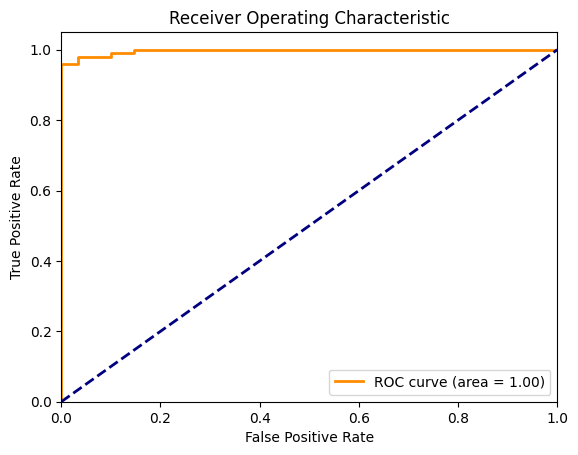

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import roc_curve, auc
from tensorflow.keras.models import load_model
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

# Define parameters
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

test_data = pd.read_csv('/content/drive/MyDrive/test_data.csv')

# Define the base path to dataset directory
base_path = '/content/drive/MyDrive/NEW'

test_data['filename'] = test_data['filename'].apply(lambda x: os.path.join(base_path, x.replace('\\', '/')))


print(test_data.head())


test_filenames = test_data['filename'].tolist()


print(all(os.path.exists(filename) for filename in test_filenames))

# Create Data Generators with preprocessing
test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

test_generator = test_datagen.flow_from_dataframe(
    test_data,
    x_col='filename',
    y_col='label',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False,
    seed=SEED
)

# Load the saved model
model = load_model('/content/path_to_save_model/dfu_mobilenetv2.h5')

# Get the predicted probabilities
y_pred_prob = model.predict(test_generator, steps=test_generator.n // BATCH_SIZE + 1)
y_true = test_generator.classes

# For binary classification, get probabilities for the positive class
y_pred_prob_positive_class = y_pred_prob[:, 1]

# Compute ROC curve and ROC area
fpr, tpr, _ = roc_curve(y_true, y_pred_prob_positive_class)
roc_auc = auc(fpr, tpr)

print(f"AUC: {roc_auc}")

# Plot ROC curve
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc='lower right')
plt.show()

                                            filename    label
0  /content/drive/MyDrive/NEW/dataset/Control gro...  Control
1  /content/drive/MyDrive/NEW/dataset/Control gro...  Control
2  /content/drive/MyDrive/NEW/dataset/DM group/DM...       DM
3  /content/drive/MyDrive/NEW/dataset/Control gro...  Control
4  /content/drive/MyDrive/NEW/dataset/Control gro...  Control
Found 187 validated image filenames belonging to 2 classes.
Sensitivity: 0.9795918367346939
Specificity: 0.9887640449438202
              precision    recall  f1-score   support

     Control       0.98      0.99      0.98        89
          DM       0.99      0.98      0.98        98

    accuracy                           0.98       187
   macro avg       0.98      0.98      0.98       187
weighted avg       0.98      0.98      0.98       187



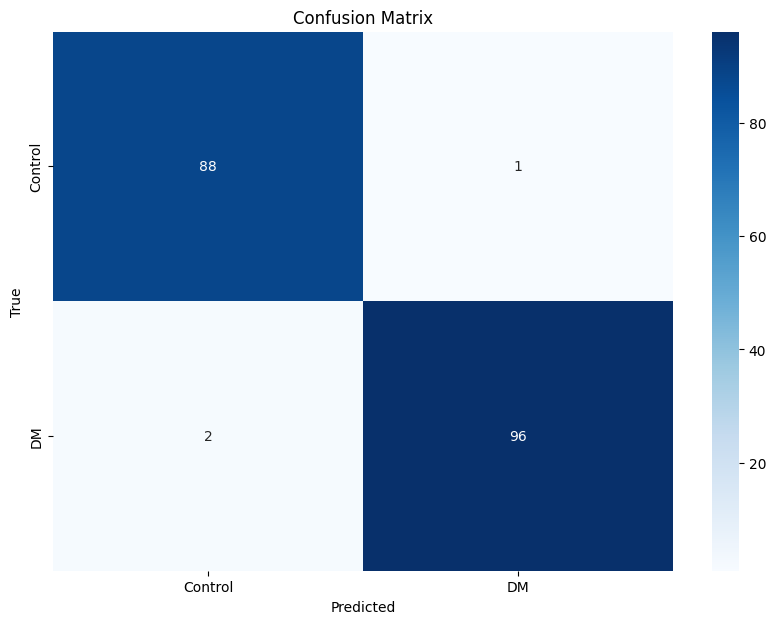

In [ ]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import seaborn as sns
import matplotlib.pyplot as plt

# Define parameters
IMG_SIZE = (224, 224)
SEED = 42

# Define the base path to your dataset directory
base_path = '/content/drive/MyDrive/NEW'

# Load the data from CSV files
test_data = pd.read_csv('/content/drive/MyDrive/NEW/test_data.csv')

# Update file paths
def update_path(filepath):
    return os.path.join(base_path, filepath.replace('\\', '/')).strip()

test_data['filename'] = test_data['filename'].apply(update_path)

# Verify updated file paths
print(test_data.head())

# Create Data Generator
test_datagen = ImageDataGenerator(preprocessing_function=tf.keras.applications.mobilenet_v2.preprocess_input)

test_generator = test_datagen.flow_from_dataframe(
    test_data,
    x_col='filename',
    y_col='label',
    target_size=IMG_SIZE,
    batch_size=1,  # Process one image at a time
    class_mode='categorical',
    shuffle=False,
    seed=SEED
)

# Load the TensorFlow Lite model
interpreter = tf.lite.Interpreter(model_path='/content/drive/MyDrive/NEW/dfu_mobilenetv2 (2).tflite')
interpreter.allocate_tensors()

# Get input and output details
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# Prepare lists to store true and predicted labels
true_labels = []
predicted_labels = []

# Iterate over each image in the test dataset
for i in range(len(test_generator)):
    inputs, label = test_generator[i]
    # Set input tensor
    interpreter.set_tensor(input_details[0]['index'], inputs)

    # Run inference
    interpreter.invoke()

    # Get output tensor
    output = interpreter.get_tensor(output_details[0]['index'])

    # Append true and predicted labels
    true_labels.append(np.argmax(label, axis=1)[0])
    predicted_labels.append(np.argmax(output, axis=1)[0])

# Convert lists to numpy arrays for evaluation
true_labels = np.array(true_labels)
predicted_labels = np.array(predicted_labels)

# Calculate confusion matrix
cm = confusion_matrix(true_labels, predicted_labels)

# Calculate sensitivity and specificity
tn, fp, fn, tp = cm.ravel()
sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)

print(f"Sensitivity: {sensitivity}")
print(f"Specificity: {specificity}")

# Classification report
report = classification_report(true_labels, predicted_labels, target_names=test_generator.class_indices.keys())
print(report)

# Plot confusion matrix
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=test_generator.class_indices.keys(), yticklabels=test_generator.class_indices.keys())
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()


# Task
Generate and visualize Grad-CAM or saliency maps for a few test images using the previously trained MobileNetV2 model.

## Load the trained model

### Subtask:
Load the saved MobileNetV2 model.


**Reasoning**:
Load the saved MobileNetV2 model using the `load_model` function.



In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [15]:
import os
# Get the path to the current notebook
# NOTEBOOK_PATH = os.path.abspath('')

# Change the current working directory to the notebook's directory
# os.chdir(os.path.dirname(NOTEBOOK_PATH))

# Change the current working directory to the desired directory
os.chdir('/content/drive/MyDrive/SWAN/InternsSWAN/DiabeticFoot_IgniSole')

print(f"Current working directory: {os.getcwd()}")

Current working directory: /content/drive/MyDrive/SWAN/InternsSWAN/DiabeticFoot_IgniSole


In [16]:
!ls

 Copyright	      DiabeticFootDetection.ipynb    ModificationsForPaper.gdoc
 dfu_mobilenetv2.h5  'diabetic foot ulcer project'   test_data.csv


Attempting to load model from: /content/drive/MyDrive/SWAN/InternsSWAN/DiabeticFoot_IgniSole/dfu_mobilenetv2.h5


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_3[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,340,098 (8.93 MB)

 Trainable params: 1,608,514 (6.14 MB)

 Non-trainable params: 731,584 (2.79 MB)

DM Image Prediction: DM
DM Image Probabilities: [0.00157282 0.99842715]


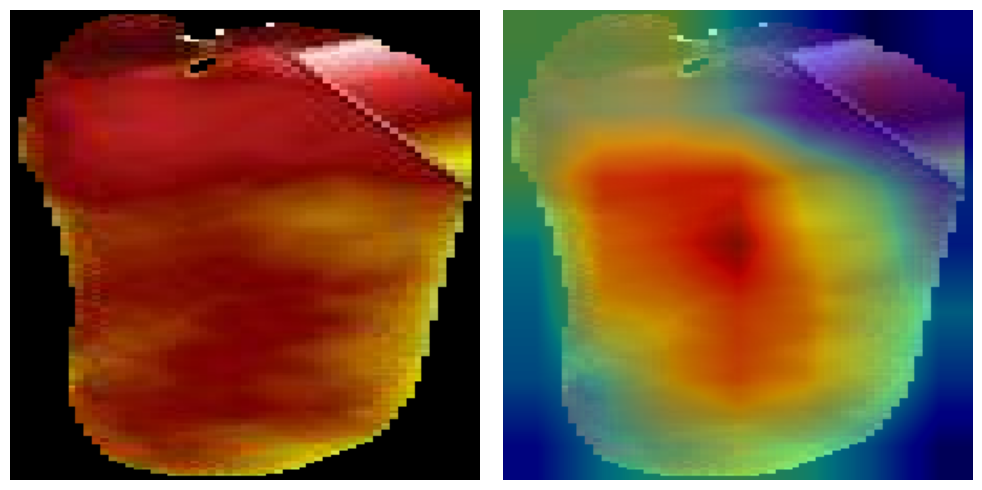

Control Image Prediction: Control
Control Image Probabilities: [0.9573831 0.0426169]


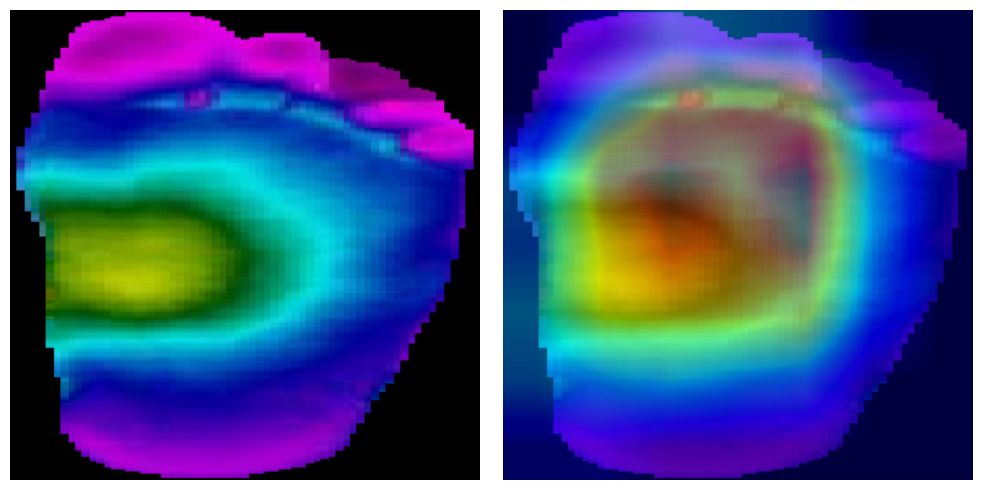

In [30]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
import matplotlib.pyplot as plt
import os
from google.colab import drive


# Load the trained model
model_path = '/content/drive/MyDrive/SWAN/InternsSWAN/DiabeticFoot_IgniSole/dfu_mobilenetv2.h5' # Define the model path - Corrected to absolute path
print(f"Attempting to load model from: {os.path.abspath(model_path)}") # Print the absolute path

# It seems there was an issue with loading the optimizer state, so we load without compiling.
# If you need to train or evaluate the model later, you'll need to compile it.
model = load_model(model_path, compile=False)

# Print the model summary to check if it loaded correctly
model.summary()

# Function to load and preprocess an image
def load_and_preprocess_image(img_path, target_size=(224, 224)):
    img = image.load_img(img_path, target_size=target_size)
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = preprocess_input(img_array)
    return img, img_array

# Function to generate saliency map using Grad-CAM approach
def generate_saliency_map(model, img_array, last_conv_layer_name='block_16_project_BN'):
    # Create a model that maps the input image to the activations of the last convolutional layer
    # and the final predictions.
    grad_model = tf.keras.models.Model(
        inputs=model.inputs,
        outputs=[model.get_layer(last_conv_layer_name).output, model.output]
    )

    # Convert numpy array to TensorFlow Tensor
    img_tensor = tf.convert_to_tensor(img_array, dtype=tf.float32)

    with tf.GradientTape() as tape:
        # Watch the input tensor
        tape.watch(img_tensor)
        # Get the activations of the last convolutional layer and the predictions
        last_conv_layer_output, predictions = grad_model(img_tensor)
        # Get the predicted class
        predicted_class = tf.argmax(predictions[0])
        # Get the loss for the predicted class
        loss = predictions[:, predicted_class]

    # Compute the gradients of the loss with respect to the activations of the last convolutional layer
    grads = tape.gradient(loss, last_conv_layer_output)

    # Compute the mean of the gradients over the spatial dimensions
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # Multiply the pooled gradients with the activations to get the saliency map
    # Expand dimensions of pooled_grads to match the shape of last_conv_layer_output for broadcasting
    pooled_grads_expanded = pooled_grads[tf.newaxis, tf.newaxis, tf.newaxis, :]
    saliency_map = last_conv_layer_output * pooled_grads_expanded
    saliency_map = tf.reduce_sum(saliency_map, axis=-1)


    # Apply ReLU to the saliency map to keep only positive contributions
    saliency_map = tf.maximum(saliency_map, 0)
    saliency_map = tf.squeeze(saliency_map).numpy()


    # Resize the saliency map to the size of the original image
    saliency_map = tf.image.resize(saliency_map[..., tf.newaxis], (img_array.shape[1], img_array.shape[2]))
    saliency_map = tf.squeeze(saliency_map).numpy()


    # Normalize the saliency map
    if np.max(saliency_map) > 0:
        saliency_map = saliency_map / np.max(saliency_map)
    else:
        saliency_map = np.zeros_like(saliency_map)


    return saliency_map, predictions[0] # Return predictions as well

# Example usage with a test image
img_path_dm = 'diabetic foot ulcer project/dataset/DM group/DM001_M_L.png'  # Relative path for image
original_img_dm, img_array_dm = load_and_preprocess_image(img_path_dm)

# Generate saliency map and get predictions for DM image
saliency_map_dm, predictions_dm = generate_saliency_map(model, img_array_dm)

# Define class labels (ensure these match your model's output)
class_labels = {0: 'Control', 1: 'DM'} # Adjust if your model has different class indices/names
predicted_class_dm = class_labels[tf.argmax(predictions_dm).numpy()]

print(f"DM Image Prediction: {predicted_class_dm}")
print(f"DM Image Probabilities: {predictions_dm.numpy()}")

# Display the original image and the saliency map for DM image
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(original_img_dm)
# plt.title(f'Original Image (Predicted: {predicted_class_dm})')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(original_img_dm)
plt.imshow(saliency_map_dm, cmap='jet', alpha=0.5)  # Overlay saliency map
# plt.title('Saliency Map')
plt.axis('off')

plt.tight_layout()
plt.savefig('diabetic.png')
plt.show()

# Example usage with a Control image
img_path_control = 'diabetic foot ulcer project/dataset/Control group/CG009_M_L.png' # Relative path for image
original_img_control, img_array_control = load_and_preprocess_image(img_path_control)

# Generate saliency map and get predictions for Control image
saliency_map_control, predictions_control = generate_saliency_map(model, img_array_control)

predicted_class_control = class_labels[tf.argmax(predictions_control).numpy()]

print(f"Control Image Prediction: {predicted_class_control}")
print(f"Control Image Probabilities: {predictions_control.numpy()}")


# Display the original image and the saliency map for Control image
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(original_img_control)
# plt.title(f'Original Image (Predicted: {predicted_class_control})')

plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(original_img_control)
plt.imshow(saliency_map_control, cmap='jet', alpha=0.5)  # Overlay saliency map
# plt.title('Saliency Map')
plt.axis('off')

plt.tight_layout()
plt.savefig('control.png')
plt.show()